In [1]:
import os

os.chdir('..')

## Loading the Dataset:

In this section the pointcloud is loaded. The SIREN paper suggests normalizing the point coordinates as periodic activations implicitly expect a bounded input. 

In [2]:
import open3d as o3d
import numpy as np
import torch
import matplotlib.pyplot as plt
import src.model.SIREN as si
from src.model.training import train
import src.loss.SDF_loss as loss

pcd = o3d.io.read_point_cloud("data/pointclouds/Armadillo/Armadillo.ply")

points = np.asarray(pcd.points)   # (N, 3)

print('Points before normalization:\n', points)

points /= np.max(np.linalg.norm(points, axis=1))
print('\n Points after:\n', points)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Points before normalization:
 [[  5.8945775   11.78840065  27.28323936]
 [-53.32511139  67.10436249 -57.45013046]
 [  3.75048876  16.50540161  29.45401955]
 ...
 [ -0.53707075  -6.22242689  42.90413666]
 [-49.76054001 -52.08040619   1.24506998]
 [-57.97610855  62.83114624 -50.2011261 ]]

 Points after:
 [[ 0.05403114  0.10805537  0.25008487]
 [-0.48879106  0.61509506 -0.526602  ]
 [ 0.0343779   0.15129256  0.26998277]
 ...
 [-0.00492292 -0.05703629  0.39326985]
 [-0.45611732 -0.47738179  0.01141262]
 [-0.53142324  0.57592571 -0.46015584]]


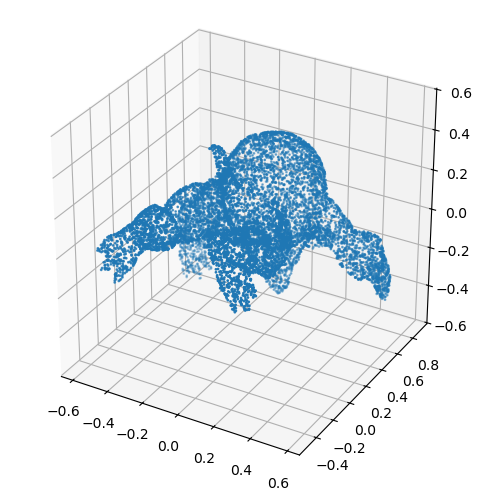

In [3]:
idx = np.random.choice(len(points), 10000, replace=False)
pts = points[idx]
x, y, z = pts[:,0], pts[:,1], pts[:,2]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=1)
ax.set_box_aspect([1, 1, 1])

plt.show()


## Defining the Model

In this cell we will define the SIREN model. This particular INR uses sine activations for nonlinearity and is supposed to capture more information given the underlying data when compared to a model that uses ReLU activations. This way, a good INR accuracy can be achieved with fewer neurons.

In [4]:
size_per_layer = 64
model = si.SIRENSDF(hidden_dim=size_per_layer, num_hidden_layers=3)
model_loss = loss.Loss(lambda_surface=1, lambda_eikonal=0.1, lambda_normal=0, normal_present=False, lambda_twd=1e-5, k=int(size_per_layer/5), model=model) # optional normal loss if normals contained in the pointcloud
optimizer = torch.optim.Adam(model.parameters())


## Model training



In [5]:
train(epochs=100, data=points, no_surface=1024, no_off_surface=2048, model=model, loss=model_loss, optimizer=optimizer, prune=True)

Pruned 0.0 neurons.
Step 0 | Loss 0.10003738850355148
Pruned 0.0 neurons.
Step 10 | Loss 0.01668669655919075
Pruned 0.0 neurons.
Step 20 | Loss 0.012835206463932991
Pruned 0.0 neurons.
Step 30 | Loss 0.011264093220233917
Pruned 0.0 neurons.
Step 40 | Loss 0.009845390915870667
Pruned 0.0 neurons.
Step 50 | Loss 0.009444891475141048
Pruned 0.0 neurons.
Step 60 | Loss 0.008768170140683651
Pruned 0.0 neurons.
Step 70 | Loss 0.008156818337738514
Pruned 0.0 neurons.
Step 80 | Loss 0.007636067923158407
Pruned 0.0 neurons.
Step 90 | Loss 0.0070641497150063515


In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Sample a few surface points and check their SDF values
test_points = points[:10]  # First 10 points
test_tensor = torch.from_numpy(test_points).float().to(device)
with torch.no_grad():
    sdf_values = model(test_tensor)
print("SDF values for surface points:")
print(sdf_values)
print("Mean absolute SDF:", torch.abs(sdf_values).mean().item())

SDF values for surface points:
tensor([[ 0.0225],
        [-0.0179],
        [ 0.0444],
        [ 0.0089],
        [-0.0216],
        [-0.0247],
        [-0.0248],
        [ 0.0487],
        [ 0.0302],
        [ 0.0177]])
Mean absolute SDF: 0.026137933135032654
